I checked the data types, and most of the columns look correct. The only issue is ride_date, which came as str instead of a date format. This probably happened because when the data was saved as a CSV, the date column became text. I will fix it later in preprocessing.ipynb using pd.to_datetime().

In [ ]:
#E1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/citibike_weather_daily.csv")

display(df.head())
print(df.shape)
display(df.dtypes)
display(df.info())

,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,month
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,32986.783230,15.425627,57.368509,67.317081,49.295901,9.013913,0.178398,6.544099
std,16910.147968,3.652633,17.876211,18.349408,17.832318,3.241211,2.508762,3.323772
min,876.000000,9.495396,8.300000,18.000000,1.000000,2.300000,0.000000,1.000000
25%,20505.500000,13.112342,43.625000,53.700000,35.700000,6.700000,0.000000,4.000000
50%,32272.500000,14.860057,59.300000,70.000000,51.100000,8.500000,0.000000,7.000000
75%,42915.750000,17.121551,73.500000,82.900000,64.900000,10.800000,0.060000,9.000000
max,78458.000000,81.110084,92.500000,100.900000,82.900000,22.400000,99.990000,12.000000


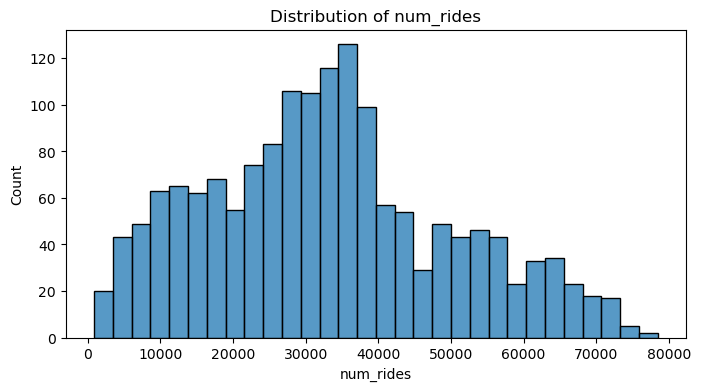

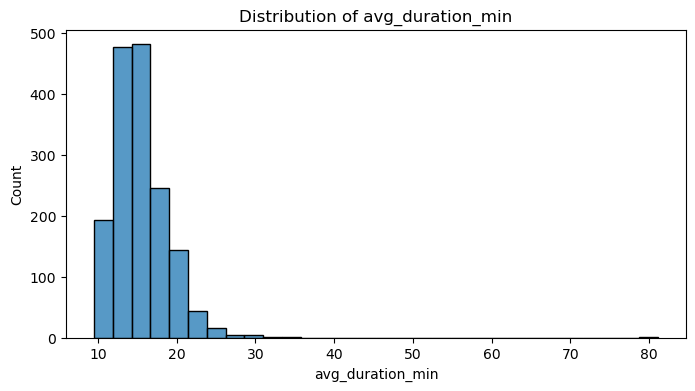

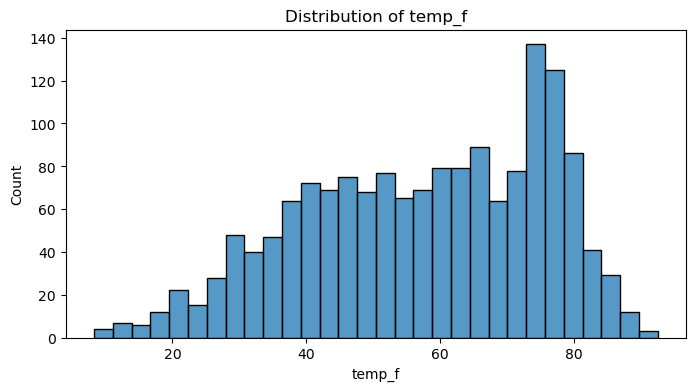

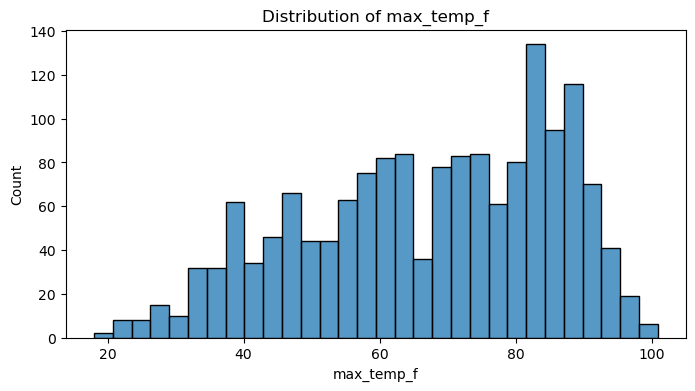

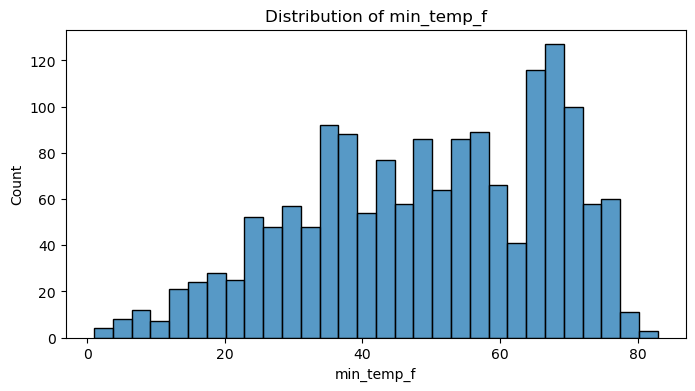

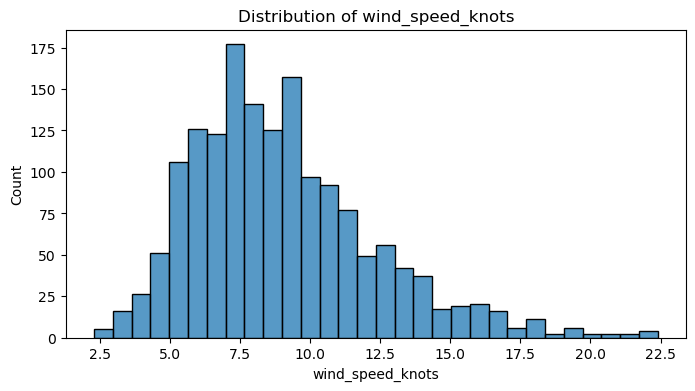

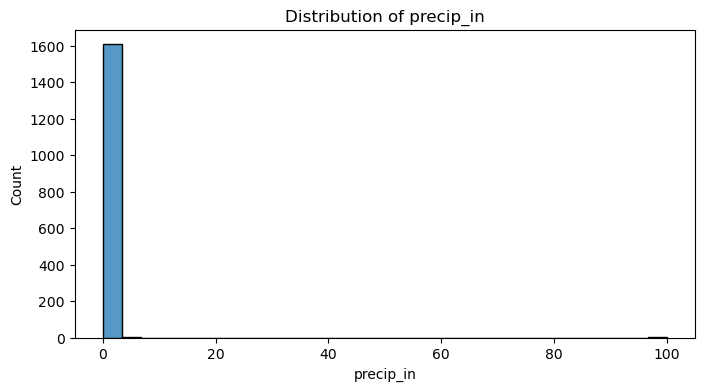

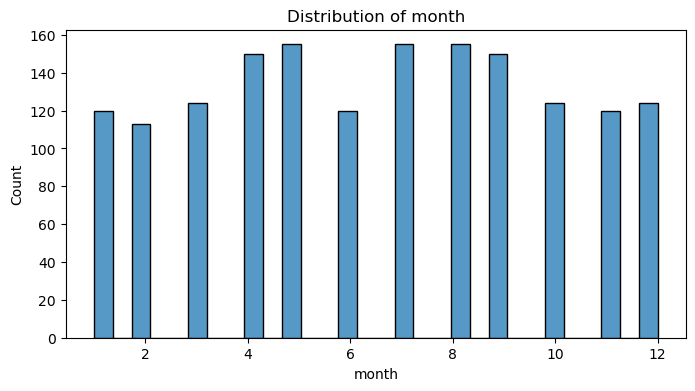

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# List only the numeric columns in the dataset
numeric_cols = [
    "num_rides",
    "avg_duration_min",
    "temp_f",
    "max_temp_f",
    "min_temp_f",
    "wind_speed_knots",
    "precip_in",
    "month"
]

# Show summary statistics: count, mean, min, max, etc.
display(df[numeric_cols].describe())

# Create one histogram for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    
    # Show how values are distributed in this column
    sns.histplot(data=df, x=col, bins=30)
    
    plt.title(f"Distribution of {col}")
    plt.show()

In [4]:
# These values can mean missing data in NOAA weather datasets
missing_codes = [9999.9, 999.9, 99.99]

# Count how many times each missing-value code appears in every numeric column
for code in missing_codes:
    print(f"\nChecking for missing code: {code}")
    display((df[numeric_cols] == code).sum())


Checking for missing code: 9999.9


num_rides           0
avg_duration_min    0
temp_f              0
max_temp_f          0
min_temp_f          0
wind_speed_knots    0
precip_in           0
month               0
dtype: int64


Checking for missing code: 999.9


num_rides           0
avg_duration_min    0
temp_f              0
max_temp_f          0
min_temp_f          0
wind_speed_knots    0
precip_in           0
month               0
dtype: int64


Checking for missing code: 99.99


num_rides           0
avg_duration_min    0
temp_f              0
max_temp_f          0
min_temp_f          0
wind_speed_knots    0
precip_in           1
month               0
dtype: int64

E2: Profile the Distributions
Run .describe() on the numeric columns and plot a histogram of each. For every column, ask: are the min and max physically possible? Document anything suspicious.
 Tip: Government datasets often encode missing values as numbers rather than leaving cells blank. NOAA's GSOD documentation says missing observations are coded as 9999.9 (temperatures), 999.9 (wind), or 99.99 (precipitation). A careful analyst checks whether any of those codes made it into their slice of the data.

In [ ]:
# Show summary statistics for all numeric columns
# We will check the min and max values for anything suspicious
display(df[numeric_cols].describe())

I checked the numeric columns with .describe(). Most values look normal. The only problem is 99.99 in precip_in, which is a missing value code, not real rain. I found it only once, so later I will change it to NaN.

E3: Relationships With the Target
Make scatter plots of num_rides against each weather variable. Which relationships look strong? Which look weak? Describe the shape of the temperature relationship in a markdown cell.
 Tip: Look closely at the very hottest days. Does ridership keep climbing forever as it gets hotter, or does something else happen? Remember this when you get to feature engineering.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Weather columns we want to compare with daily rides
weather_cols = [
    "temp_f",
    "max_temp_f",
    "min_temp_f",
    "wind_speed_knots",
    "precip_in"
]

# Make one scatter plot for each weather column
for col in weather_cols:
    plt.figure(figsize=(8, 4))
    
    # X-axis = one weather variable, Y-axis = daily number of rides
    sns.scatterplot(data=df, x=col, y="num_rides", alpha=0.6)
    
    plt.title(f"Number of rides vs {col}")
    plt.xlabel(col)
    plt.ylabel("Number of rides")
    plt.show()

Temperature has the strongest relationship with daily rides. In general, ridership is higher on warm days than on cold days. However, the number of rides does not keep increasing forever when the temperature goes up. On very hot days, the rides are more spread out and may not be as high.

Wind has a weak negative relationship with rides because higher wind can mean fewer rides, but the pattern is not very clear. Most precipitation values are close to zero, and the value 99.99 is missing data, so I will change it to NaN later.

E4: Ridership Over Time
Plot num_rides over the full date range. Then compare the same month across different years — for example, average July ridership in 2013 vs. 2015 vs. 2017.
In a markdown cell: is a July day in 2017 the same as a July day in 2013, even at identical weather? What does that mean for a model whose only inputs are weather and day-of-week?
 Tip: The bike share system itself changed over these six years: more stations, more bikes, more members. Your model needs some way to know what year it is.

In [7]:
# Make a copy so we do not change the original dataset yet
eda_df = df.copy()

# Convert ride_date from text to a real date format
# We need this before making time-based charts
eda_df["ride_date"] = pd.to_datetime(eda_df["ride_date"])

# Create a year column from ride_date
eda_df["year"] = eda_df["ride_date"].dt.year

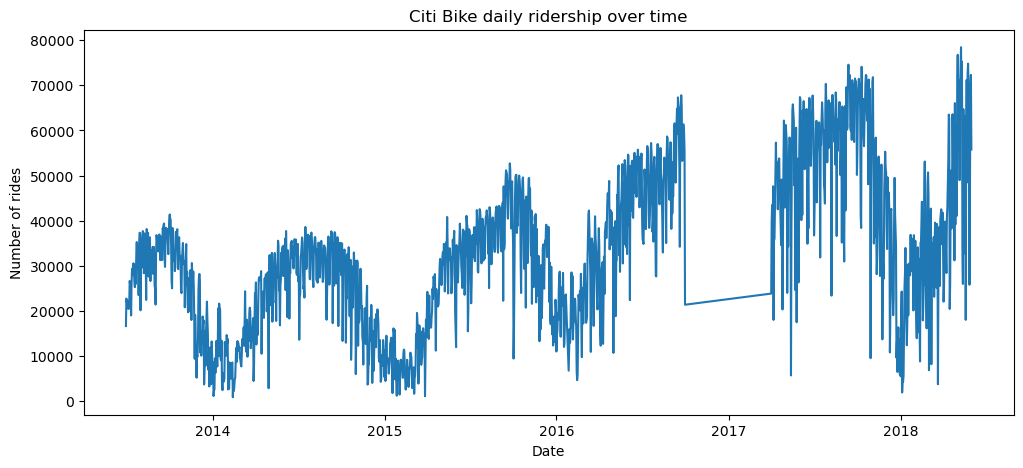

In [8]:
# Create a line plot to see ridership over the full date range
plt.figure(figsize=(12, 5))

sns.lineplot(data=eda_df, x="ride_date", y="num_rides")

plt.title("Citi Bike daily ridership over time")
plt.xlabel("Date")
plt.ylabel("Number of rides")
plt.show()

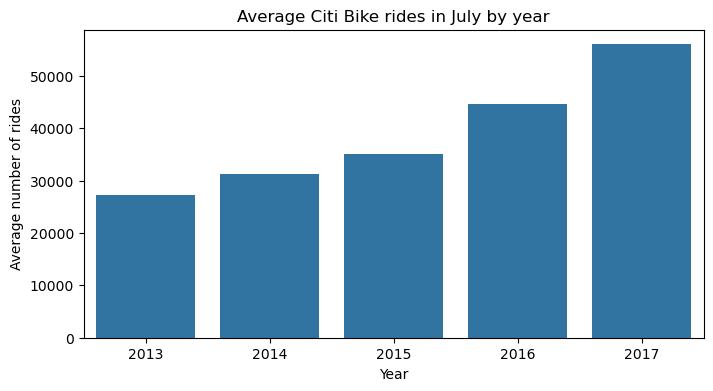

In [9]:
# Keep only rows where the month is July
july_df = eda_df[eda_df["month"] == 7]

# Calculate the average number of rides in July for each year
july_by_year = july_df.groupby("year", as_index=False)["num_rides"].mean()

# Make a bar chart for average July ridership by year
plt.figure(figsize=(8, 4))

sns.barplot(data=july_by_year, x="year", y="num_rides")

plt.title("Average Citi Bike rides in July by year")
plt.xlabel("Year")
plt.ylabel("Average number of rides")
plt.show()

The time series shows that Citi Bike ridership has a seasonal pattern. There are more rides in warm months and fewer rides in cold months.

The July chart also shows that ridership increased every year, from around 27,000 average rides in 2013 to around 56,000 in 2017. This means I should include a time or year feature in the model, because the Citi Bike system grew over time.

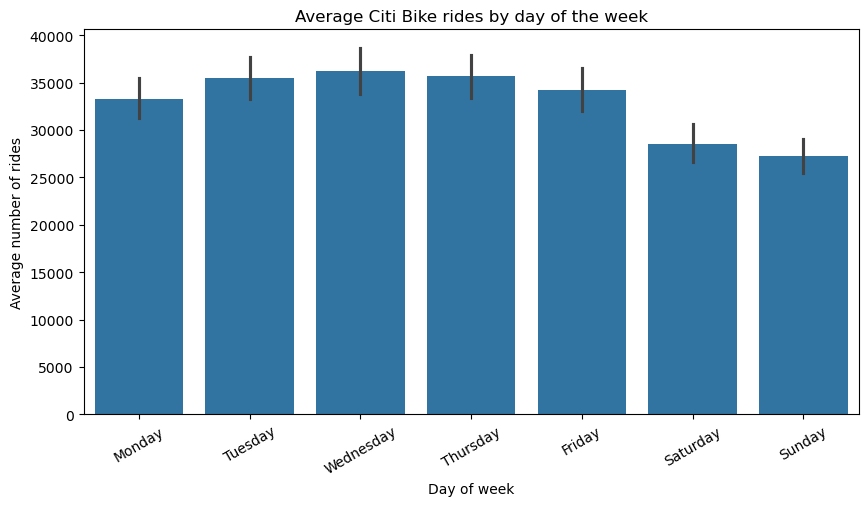

In [10]:
# Put the days in the normal Monday-to-Sunday order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Create a bar chart showing the average rides for each day
plt.figure(figsize=(10, 5))

sns.barplot(
    data=eda_df,
    x="day_of_week",
    y="num_rides",
    order=day_order
)

plt.title("Average Citi Bike rides by day of the week")
plt.xlabel("Day of week")
plt.ylabel("Average number of rides")
plt.xticks(rotation=30)
plt.show()

The chart shows that Citi Bike has more rides on weekdays than on weekends. Wednesday has the highest average ridership, while Sunday has the lowest. This could be because many people use Citi Bike for commuting during the work week.
image.jpg

In [11]:
# Make sure ride_date is a real date format
eda_df["ride_date"] = pd.to_datetime(eda_df["ride_date"])

# Find the first and last date in the dataset
min_date = eda_df["ride_date"].min()
max_date = eda_df["ride_date"].max()

# Create every calendar date between the first and last date
all_dates = pd.date_range(start=min_date, end=max_date, freq="D")

# Get the dates that exist in our dataset
actual_dates = pd.DatetimeIndex(eda_df["ride_date"].unique())

# Find dates that should exist but are missing
missing_dates = all_dates.difference(actual_dates)

# Print the main results
print("First date:", min_date.date())
print("Last date:", max_date.date())
print("Expected number of dates:", len(all_dates))
print("Number of dates in dataset:", len(actual_dates))
print("Missing dates:", len(missing_dates))

# Show the actual missing dates
display(pd.DataFrame({"missing_date": missing_dates}))

First date: 2013-07-01
Last date: 2018-05-31
Expected number of dates: 1796
Number of dates in dataset: 1610
Missing dates: 186


,missing_date
0,2016-01-23
1,2016-01-24
2,2016-01-25
3,2016-01-26
4,2016-10-01
...,...
181,2017-03-27
182,2017-03-28
183,2017-03-29
184,2017-03-30


In [12]:
# Make a table from the missing dates
missing_df = pd.DataFrame({"missing_date": missing_dates})

# Create year and month columns from each missing date
missing_df["year"] = missing_df["missing_date"].dt.year
missing_df["month"] = missing_df["missing_date"].dt.month

# Count how many missing dates appear in each year and month
missing_by_month = (
    missing_df.groupby(["year", "month"])
    .size()
    .reset_index(name="missing_days")
)

# Show the result
display(missing_by_month)

,year,month,missing_days
0,2016,1,4
1,2016,10,31
2,2016,11,30
3,2016,12,31
4,2017,1,31
5,2017,2,28
6,2017,3,31


I found 186 missing dates: four days in January 2016 and a larger gap from October 2016 to March 2017. In Part 1, daily_rides was the left side of the LEFT JOIN, so every date with Citi Bike trip data should stay in the final table. Because these dates are missing completely, the gaps most likely came from the Citi Bike trips data, not the weather data.